In [100]:
print("Installing dependencies...")
!conda install -c conda-forge ta-lib -y
!pip install "stable-baselines3[extra]" gymnasium yfinance tensorflow sklearn matplotlib pandas
print("Dependencies installed.")

Installing dependencies...
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 24.3.0
  latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=25.1.1



# All requested packages already installed.

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipf

In [101]:
# 셀 2: 라이브러리 임포트
%matplotlib inline
print("Importing libraries...")
import yfinance as yf
import numpy as np
import pandas as pd
import talib
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
print("Libraries imported.")

Importing libraries...
Libraries imported.


In [102]:
# 셀 3: 10년치 데이터 로딩 및 강화된 전처리 (수정)
print("Loading 10-year AAPL daily data...")
data = yf.download("AAPL", period="10y", interval="1d")
print("Raw data shape:", data.shape)

# 결측치 보간 및 초기 NaN 제거
data = data.interpolate(method='linear').dropna()
print("After initial NaN removal shape:", data.shape)

# 기본 데이터 준비
close = data['Close'].to_numpy().flatten()
volume = data['Volume'].to_numpy().flatten()
print("Close shape:", close.shape)
print("Volume shape:", volume.shape)

# TA-Lib 피처 계산 (1차원 보장)
rsi = talib.RSI(close, timeperiod=14).flatten()
macd, macd_signal, _ = talib.MACD(close)
macd = macd.flatten()
macd_signal = macd_signal.flatten()  # 사용하지 않지만 확인용
sma_20 = talib.SMA(close, timeperiod=20).flatten()
ema_10 = talib.EMA(close, timeperiod=10).flatten()
sma_50 = talib.SMA(close, timeperiod=50).flatten()
ema_close = talib.EMA(close, timeperiod=5).flatten()

# 디버깅: 각 피처의 shape와 차원 출력
print("RSI shape:", rsi.shape, "ndim:", rsi.ndim)
print("MACD shape:", macd.shape, "ndim:", macd.ndim)
print("SMA_20 shape:", sma_20.shape, "ndim:", sma_20.ndim)
print("EMA_10 shape:", ema_10.shape, "ndim:", ema_10.ndim)
print("SMA_50 shape:", sma_50.shape, "ndim:", sma_50.ndim)
print("EMA_Close shape:", ema_close.shape, "ndim:", ema_close.ndim)

# DataFrame 재구성 (모든 입력을 명시적으로 1차원으로)
df = pd.DataFrame({
    'Open': data['Open'].to_numpy().flatten(),
    'High': data['High'].to_numpy().flatten(),
    'Low': data['Low'].to_numpy().flatten(),
    'Close': data['Close'].to_numpy().flatten(),
    'Volume': volume,
    'RSI': rsi,
    'MACD': macd,
    'SMA_20': sma_20,
    'EMA_10': ema_10,
    'SMA_50': sma_50,
    'EMA_Close': ema_close
}, index=data.index)

# 추가 피처
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Close'].rolling(window=20).std()
df['Trend'] = df['Close'] - df['SMA_50']

# NaN 제거 (TA-Lib 피처로 인한 NaN 포함)
df = df.dropna()
print("After TA-Lib preprocessing shape:", df.shape)

# 이상치 제거 (IQR 기반)
for col in ['Close', 'Volume', 'Log_Return', 'Volatility']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# 최종 NaN 제거
data = df.dropna()
print("After preprocessing shape:", data.shape)
if data.empty:
    raise ValueError("Data is empty after preprocessing.")

# 데이터 상태 확인
print("Data sample:")
print(data.tail())
print("Data preprocessing completed.")

Loading 10-year AAPL daily data...


[*********************100%***********************]  1 of 1 completed

Raw data shape: (2515, 5)
After initial NaN removal shape: (2515, 5)
Close shape: (2515,)
Volume shape: (2515,)
RSI shape: (2515,) ndim: 1
MACD shape: (2515,) ndim: 1
SMA_20 shape: (2515,) ndim: 1
EMA_10 shape: (2515,) ndim: 1
SMA_50 shape: (2515,) ndim: 1
EMA_Close shape: (2515,) ndim: 1
After TA-Lib preprocessing shape: (2466, 14)
After preprocessing shape: (2215, 14)
Data sample:
                  Open        High         Low       Close    Volume  \
Date                                                                   
2025-03-05  235.419998  236.550003  229.229996  235.740005  47227600   
2025-03-06  234.440002  237.860001  233.160004  235.330002  45170400   
2025-03-07  235.110001  241.369995  234.759995  239.070007  46273600   
2025-03-11  223.809998  225.839996  217.449997  220.839996  76137400   
2025-03-12  220.139999  221.750000  214.910004  216.979996  62547500   

                  RSI      MACD      SMA_20      EMA_10      SMA_50  \
Date                                  

In [103]:
# 셀 4: 개선된 LSTM 모델 정의 및 학습
def create_lstm_model(input_shape, output_steps=5):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Bidirectional(LSTM(100, return_sequences=True)))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(100)))
    model.add(Dropout(0.2))
    model.add(Dense(output_steps))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def prepare_lstm_data(df, lookback=10, forecast_steps=5):
    if len(df) < lookback + forecast_steps:
        raise ValueError(f"Data too small: {len(df)} rows, need at least {lookback + forecast_steps}.")
    features = ['Close', 'RSI', 'MACD', 'SMA_20', 'EMA_10', 'Volume', 'Log_Return', 'Volatility', 'Trend']
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df[features])
    target_scaler = RobustScaler()
    scaled_target = target_scaler.fit_transform(df[['Close']])
    X, y = [], []
    for i in range(lookback, len(df) - forecast_steps):
        X.append(scaled_data[i-lookback:i])
        y.append(scaled_target[i:i+forecast_steps].flatten())
    X = np.array(X)
    y = np.array(y)
    print("X shape:", X.shape, "y shape:", y.shape)
    return X, y, scaler, target_scaler

print("Preparing LSTM data...")
lookback = 10
forecast_steps = 5
X, y, scaler, target_scaler = prepare_lstm_data(data, lookback, forecast_steps)
print("Creating LSTM model...")
lstm_model = create_lstm_model((lookback, 9), forecast_steps)  # 9 피처
print("Training LSTM model with 10-year data...")
lstm_model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
print("LSTM training completed.")

Preparing LSTM data...
X shape: (2200, 10, 9) y shape: (2200, 5)
Creating LSTM model...
Training LSTM model with 10-year data...
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0515 - val_loss: 0.0238
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039 - val_loss: 0.0189
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0089
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - val_loss: 0.0090
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0026 - val_loss: 0.0040
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025 - val_loss: 0.0042
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0024 - val_loss: 0.0102
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022 - val_loss: 0.0049
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023 - val_loss: 0.0198
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022 - val_loss: 0.0076
Epoch 11/20
62/62 ━━

In [104]:
# 셀 5: 강화학습 환경 정의
class TradingEnv(Env):
    def __init__(self, df, lstm_model, scaler, target_scaler):
        super().__init__()
        self.df = df.reset_index()
        self.lstm_model = lstm_model
        self.scaler = scaler
        self.target_scaler = target_scaler
        self.action_space = Discrete(3)
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)  # 9 피처
        self.current_step = None
        self.balance = 1000
        self.shares_held = 0
        self.buy_price = 0
        self.lookback = 10

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        lstm_input = self.df[['Close', 'RSI', 'MACD', 'SMA_20', 'EMA_10', 'Volume', 'Log_Return', 'Volatility', 'Trend']].iloc[self.current_step-self.lookback:self.current_step].values
        scaled_input = self.scaler.transform(lstm_input)
        predicted_prices_scaled = self.lstm_model.predict(scaled_input.reshape(1, self.lookback, 9), verbose=0)[0]
        predicted_prices = self.target_scaler.inverse_transform(predicted_prices_scaled.reshape(1, -1))[0]
        obs = np.array([
            row["Close"].item(),
            predicted_prices[0],
            row["RSI"].item(),
            row["MACD"].item(),
            row["SMA_20"].item(),
            row["EMA_10"].item(),
            row["Volume"].item(),
            row["Log_Return"].item(),
            row["Volatility"].item()
        ], dtype=np.float32)
        return obs

    def reset(self, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.current_step = self.lookback
        self.balance = 1000
        self.shares_held = 0
        self.buy_price = 0
        return self._get_obs(), {}

    def step(self, action):
        row = self.df.iloc[self.current_step]
        price = row["Close"].item()
        reward = 0
        if action == 1 and self.balance >= price:
            self.buy_price = price
            self.shares_held += 1
            self.balance -= price
        elif action == 2 and self.shares_held > 0:
            self.shares_held -= 1
            self.balance += price
            reward = (price - self.buy_price) / self.buy_price
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1
        truncated = False
        return self._get_obs(), reward, done, truncated, {}

print("TradingEnv defined with LSTM and TA-Lib.")

TradingEnv defined with LSTM and TA-Lib.


Creating environment...
Checking environment...


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

Creating PPO model...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training PPO model with LSTM and TA-Lib...


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

-----------------------------
| time/              |      |
|    fps             | 43   |
|    iterations      | 1    |
|    time_elapsed    | 47   |
|    total_timesteps | 2048 |
-----------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.2e+03     |
|    ep_rew_mean          | 1.81        |
| time/                   |             |
|    fps                  | 43          |
|    iterations           | 4           |
|    time_elapsed         | 190         |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.009458645 |
|    clip_fraction        | 0.0459      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | 0           |
|    learning_rate        | 0.0003      |
|    loss                 | 0.011       |
|    n_updates            | 30          |
|    policy_gradient_loss | -0.00282    |
|    value_loss           | 0.00494     |
-----------------------------------------


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 2.2e+03   |
|    ep_rew_mean          | 1.93      |
| time/                   |           |
|    fps                  | 43        |
|    iterations           | 5         |
|    time_elapsed         | 237       |
|    total_timesteps      | 10240     |
| train/                  |           |
|    approx_kl            | 0.0078732 |
|    clip_fraction        | 0.0363    |
|    clip_range           | 0.2       |
|    entropy_loss         | -1.09     |
|    explained_variance   | 0         |
|    learning_rate        | 0.0003    |
|    loss                 | -0.018    |
|    n_updates            | 40        |
|    policy_gradient_loss | -0.00266  |
|    value_loss           | 0.00475   |
---------------------------------------


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

PPO training completed.


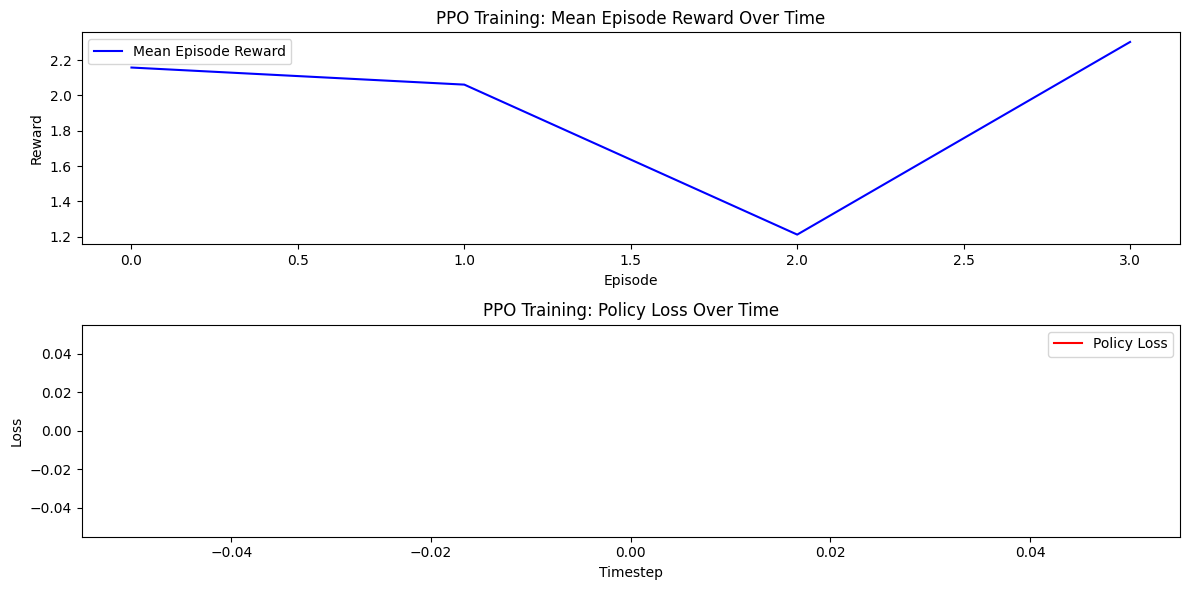

PPO training visualization completed.


In [105]:
# 셀 6: 환경 생성, PPO 학습
class TrainingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(TrainingCallback, self).__init__(verbose)
        self.rewards = []
        self.losses = []

    def _on_step(self):
        if "infos" in self.locals:
            for info in self.locals["infos"]:
                if "episode" in info:
                    self.rewards.append(info["episode"]["r"])
        if "loss" in self.locals:
            self.losses.append(self.locals["loss"])
        return True

print("Creating environment...")
env = TradingEnv(data, lstm_model, scaler, target_scaler)
print("Checking environment...")
check_env(env)
print("Creating PPO model...")
model = PPO("MlpPolicy", env, verbose=1)
callback = TrainingCallback()

print("Training PPO model with LSTM and TA-Lib...")
model.learn(total_timesteps=10000, callback=callback)
print("PPO training completed.")

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(callback.rewards, label="Mean Episode Reward", color="blue")
plt.title("PPO Training: Mean Episode Reward Over Time")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(callback.losses, label="Policy Loss", color="red")
plt.title("PPO Training: Policy Loss Over Time")
plt.xlabel("Timestep")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()
print("PPO training visualization completed.")

Starting test with 2024 data...
2024 data shape: (240, 14)
Step: 11, Date: 2024-01-19, Action: 2, Reward: 0.0000, Balance: 1000.00, Hold Balance: 1015.53
Step: 12, Date: 2024-01-22, Action: 1, Reward: 0.0000, Balance: 809.58, Hold Balance: 1027.89
Step: 13, Date: 2024-01-23, Action: 1, Reward: 0.0000, Balance: 616.85, Hold Balance: 1034.72
Step: 14, Date: 2024-01-24, Action: 0, Reward: 0.0000, Balance: 616.85, Hold Balance: 1031.12
Step: 15, Date: 2024-01-25, Action: 2, Reward: 0.0031, Balance: 810.19, Hold Balance: 1029.37
Step: 16, Date: 2024-01-26, Action: 0, Reward: 0.0000, Balance: 810.19, Hold Balance: 1020.09


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

Step: 17, Date: 2024-01-29, Action: 0, Reward: 0.0000, Balance: 810.19, Hold Balance: 1016.43
Step: 18, Date: 2024-01-30, Action: 0, Reward: 0.0000, Balance: 810.19, Hold Balance: 996.87
Step: 19, Date: 2024-01-31, Action: 1, Reward: 0.0000, Balance: 623.27, Hold Balance: 977.58
Step: 20, Date: 2024-02-01, Action: 0, Reward: 0.0000, Balance: 623.27, Hold Balance: 990.62
Step: 21, Date: 2024-02-02, Action: 1, Reward: 0.0000, Balance: 437.53, Hold Balance: 985.26
Step: 22, Date: 2024-02-05, Action: 2, Reward: -0.0054, Balance: 622.27, Hold Balance: 994.96
Step: 23, Date: 2024-02-06, Action: 0, Reward: 0.0000, Balance: 622.27, Hold Balance: 1003.55
Step: 24, Date: 2024-02-07, Action: 2, Reward: 0.0131, Balance: 810.44, Hold Balance: 1004.14
Step: 25, Date: 2024-02-08, Action: 1, Reward: 0.0000, Balance: 622.16, Hold Balance: 998.36


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

Step: 26, Date: 2024-02-09, Action: 2, Reward: -0.0058, Balance: 809.35, Hold Balance: 1002.44
Step: 27, Date: 2024-02-12, Action: 2, Reward: -0.0017, Balance: 997.32, Hold Balance: 993.42
Step: 28, Date: 2024-02-13, Action: 0, Reward: 0.0000, Balance: 997.32, Hold Balance: 982.22
Step: 29, Date: 2024-02-14, Action: 2, Reward: 0.0000, Balance: 997.32, Hold Balance: 977.50
Step: 30, Date: 2024-02-15, Action: 2, Reward: 0.0000, Balance: 997.32, Hold Balance: 975.96
Step: 31, Date: 2024-02-16, Action: 0, Reward: 0.0000, Balance: 997.32, Hold Balance: 967.73
Step: 32, Date: 2024-02-20, Action: 0, Reward: 0.0000, Balance: 997.32, Hold Balance: 963.75
Step: 33, Date: 2024-02-21, Action: 0, Reward: 0.0000, Balance: 997.32, Hold Balance: 967.78
Step: 34, Date: 2024-02-22, Action: 0, Reward: 0.0000, Balance: 997.32, Hold Balance: 978.66


...

/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

Step: 44, Date: 2024-03-07, Action: 2, Reward: -0.0059, Balance: 994.48, Hold Balance: 897.08
Step: 45, Date: 2024-03-08, Action: 1, Reward: 0.0000, Balance: 826.27, Hold Balance: 906.26
Step: 46, Date: 2024-03-11, Action: 0, Reward: 0.0000, Balance: 826.27, Hold Balance: 916.98
Step: 47, Date: 2024-03-12, Action: 2, Reward: 0.0222, Balance: 998.21, Hold Balance: 919.53
Step: 48, Date: 2024-03-13, Action: 2, Reward: 0.0000, Balance: 998.21, Hold Balance: 908.38
Step: 49, Date: 2024-03-14, Action: 1, Reward: 0.0000, Balance: 827.89, Hold Balance: 918.31
Step: 50, Date: 2024-03-15, Action: 1, Reward: 0.0000, Balance: 655.70, Hold Balance: 916.29
Step: 51, Date: 2024-03-18, Action: 1, Reward: 0.0000, Balance: 483.89, Hold Balance: 922.13
Step: 52, Date: 2024-03-19, Action: 1, Reward: 0.0000, Balance: 310.99, Hold Balance: 934.66


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

Step: 53, Date: 2024-03-20, Action: 0, Reward: 0.0000, Balance: 310.99, Hold Balance: 948.41
Step: 54, Date: 2024-03-22, Action: 2, Reward: 0.0285, Balance: 488.82, Hold Balance: 914.49
Step: 55, Date: 2024-03-25, Action: 0, Reward: 0.0000, Balance: 488.82, Hold Balance: 906.90
Step: 56, Date: 2024-03-26, Action: 2, Reward: -0.0165, Balance: 658.87, Hold Balance: 900.85
Step: 57, Date: 2024-03-27, Action: 0, Reward: 0.0000, Balance: 658.87, Hold Balance: 919.96
Step: 58, Date: 2024-03-28, Action: 2, Reward: -0.0024, Balance: 831.36, Hold Balance: 910.24
Step: 59, Date: 2024-04-01, Action: 2, Reward: -0.0129, Balance: 1002.03, Hold Balance: 902.54
Step: 60, Date: 2024-04-02, Action: 0, Reward: 0.0000, Balance: 1002.03, Hold Balance: 896.23


/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feat

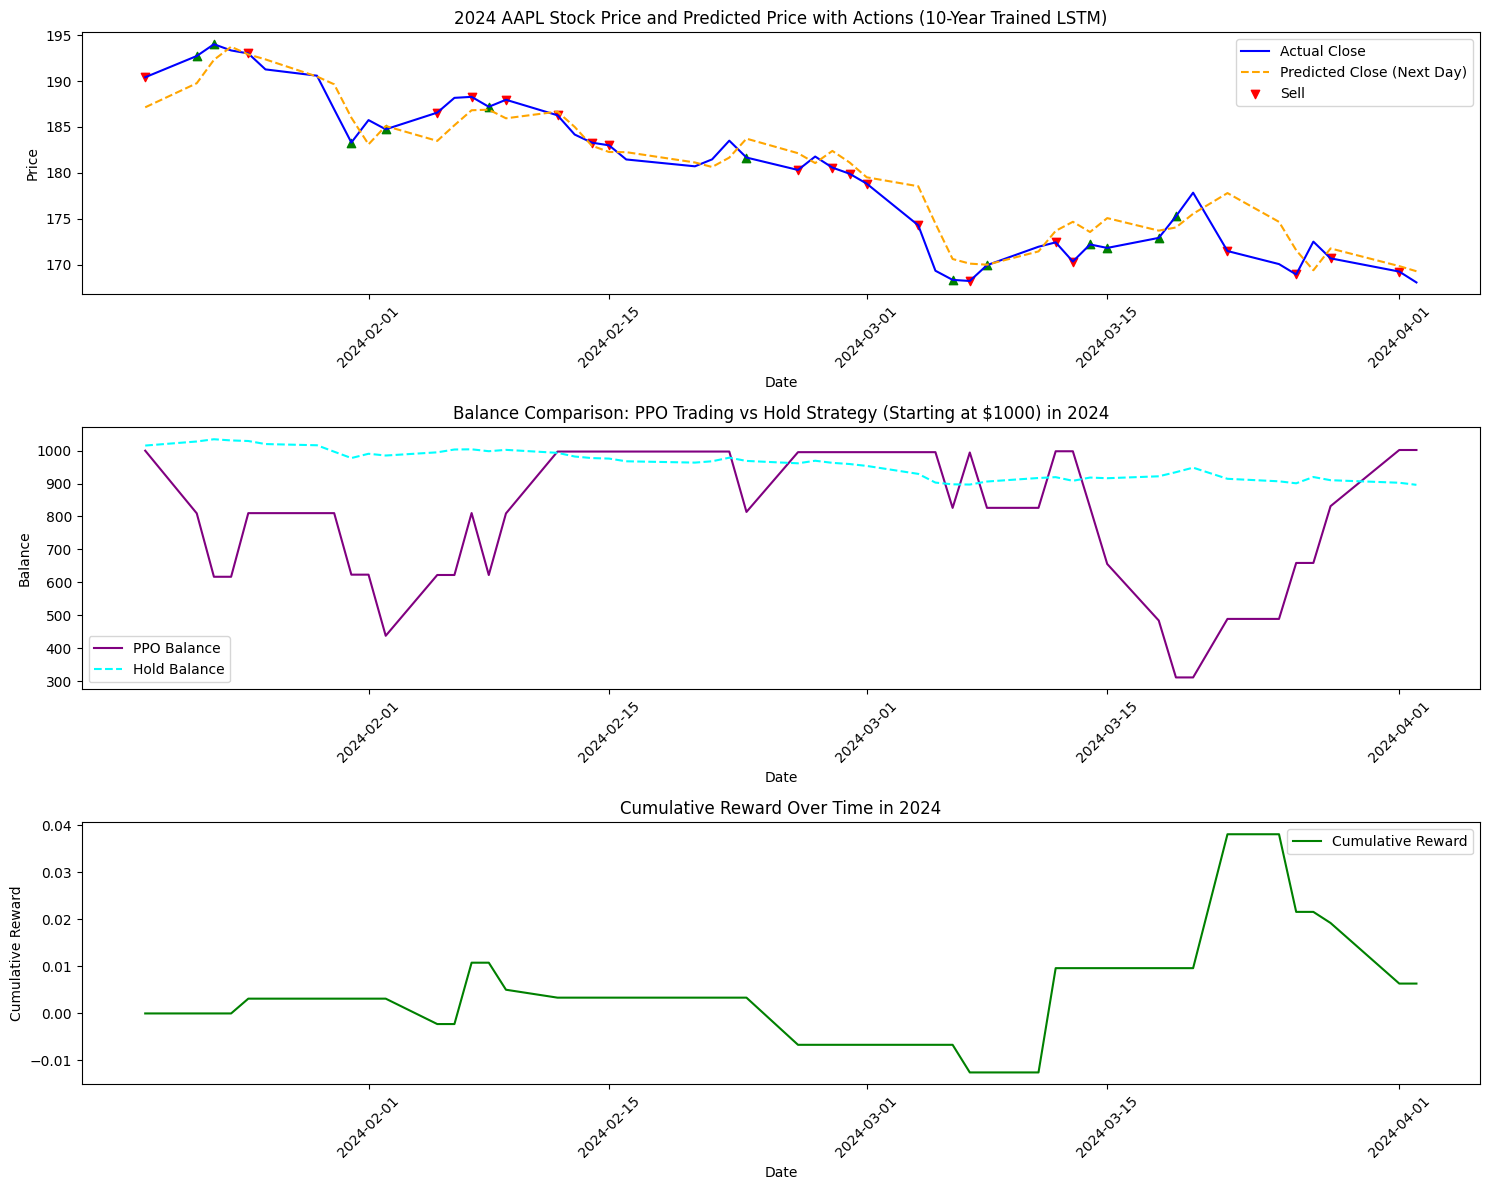

2024 test visualization completed.


In [106]:
# 셀 7: 2024년 데이터로 테스트 실행 및 시각화 (수정)
print("Starting test with 2024 data...")
data_2024 = data.loc['2024-01-01':'2024-12-31']
if len(data_2024) < lookback + 50:
    raise ValueError(f"Insufficient 2024 data: {len(data_2024)} days available, need at least {lookback + 50}.")
print(f"2024 data shape: {data_2024.shape}")

env_2024 = TradingEnv(data_2024, lstm_model, scaler, target_scaler)

dates = []
closes = []
predicted_prices = []
balances = []
hold_balances = []  # Hold 전략 잔고 추가
rewards = []
actions = []

obs, _ = env_2024.reset()
initial_balance = 1000  # 초기 자금
first_close = data_2024['Close'].iloc[lookback]  # 첫날 종가 (lookback 이후 첫 데이터)
shares_held_hold = initial_balance / first_close  # Hold 전략: 첫날 매수 주식 수

for _ in range(50):
    action, _states = model.predict(obs)
    obs, reward, done, truncated, info = env_2024.step(action)
    row = env_2024.df.iloc[env_2024.current_step]
    
    date_value = row["Date"]
    date_str = date_value.strftime('%Y-%m-%d') if isinstance(date_value, pd.Timestamp) else str(date_value)
    
    dates.append(date_value)
    closes.append(row["Close"].item())
    predicted_prices.append(obs[1])
    balances.append(env_2024.balance)
    hold_balances.append(shares_held_hold * row["Close"].item())  # Hold 잔고: 주식 수 * 현재 가격
    rewards.append(reward)
    actions.append(action)
    
    print(f"Step: {env_2024.current_step}, Date: {date_str}, Action: {action}, Reward: {reward:.4f}, Balance: {env_2024.balance:.2f}, Hold Balance: {hold_balances[-1]:.2f}")
    if done or truncated:
        break

# 시각화: 가격, 잔고 비교, 누적 보상
plt.figure(figsize=(15, 12))

# 1. 주식 가격과 예측 가격
plt.subplot(3, 1, 1)
plt.plot(dates, closes, label="Actual Close", color="blue")
plt.plot(dates, predicted_prices, label="Predicted Close (Next Day)", color="orange", linestyle="--")
for i, action in enumerate(actions):
    if action == 1:
        plt.scatter(dates[i], closes[i], color="green", marker="^", label="Buy" if i == 0 else "")
    elif action == 2:
        plt.scatter(dates[i], closes[i], color="red", marker="v", label="Sell" if i == 0 else "")
plt.title("2024 AAPL Stock Price and Predicted Price with Actions (10-Year Trained LSTM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

# 2. PPO 잔고와 Hold 잔고 비교
plt.subplot(3, 1, 2)
plt.plot(dates, balances, label="PPO Balance", color="purple")
plt.plot(dates, hold_balances, label="Hold Balance", color="cyan", linestyle="--")
plt.title("Balance Comparison: PPO Trading vs Hold Strategy (Starting at $1000) in 2024")
plt.xlabel("Date")
plt.ylabel("Balance")
plt.legend()
plt.xticks(rotation=45)

# 3. 누적 보상
plt.subplot(3, 1, 3)
cumulative_rewards = np.cumsum(rewards)
plt.plot(dates, cumulative_rewards, label="Cumulative Reward", color="green")
plt.title("Cumulative Reward Over Time in 2024")
plt.xlabel("Date")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("2024 test visualization completed.")

Fetching latest AAPL data for prediction...


[*********************100%***********************]  1 of 1 completed
/Users/ihagjun/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


Latest data shape: (59, 5)
Latest data after preprocessing shape: (10, 14)
Latest data columns: MultiIndex([(      'Close', 'AAPL'),
            (       'High', 'AAPL'),
            (        'Low', 'AAPL'),
            (       'Open', 'AAPL'),
            (     'Volume', 'AAPL'),
            (        'RSI',     ''),
            (       'MACD',     ''),
            ('MACD_signal',     ''),
            (     'SMA_20',     ''),
            (     'EMA_10',     ''),
            ( 'Log_Return',     ''),
            ( 'Volatility',     ''),
            (     'SMA_50',     ''),
            (  'EMA_Close',     '')],
           names=['Price', 'Ticker'])
Latest data index: DatetimeIndex(['2025-03-11', '2025-03-12', '2025-03-13', '2025-03-14',
               '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
               '2025-03-21', '2025-03-24'],
              dtype='datetime64[ns]', name='Date', freq=None)
Close index: DatetimeIndex(['2025-03-11', '2025-03-12', '2025-03-13', '2025-03-1

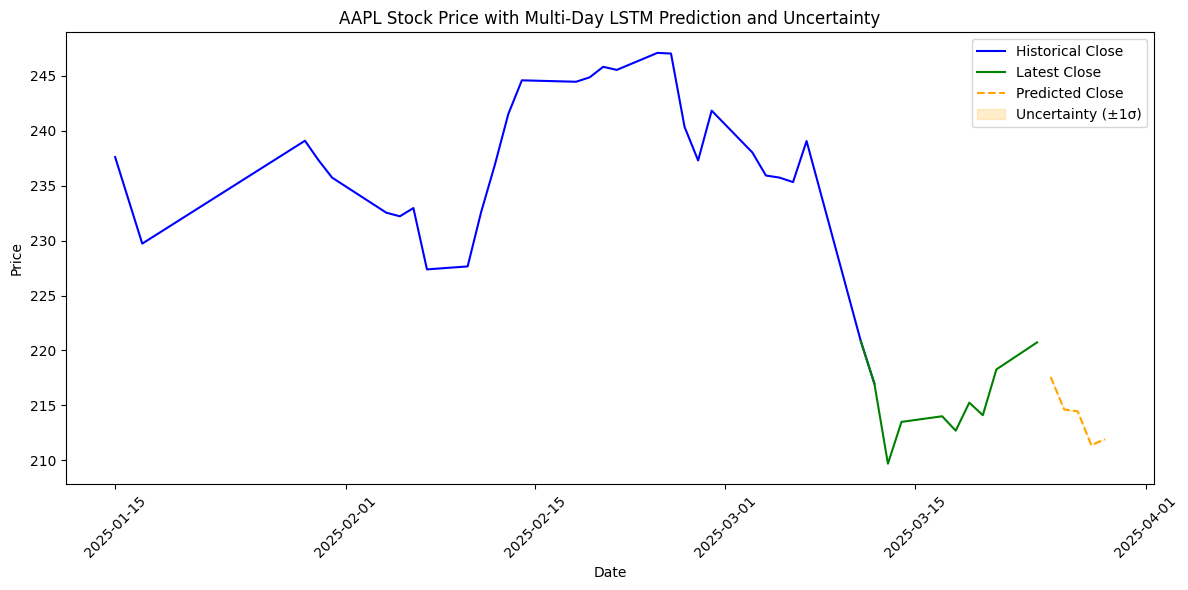

Multi-day prediction visualization completed.


In [107]:
# 셀 8: 다중 날짜 예측 및 불확실성 시각화 (수정)
print("Fetching latest AAPL data for prediction...")
latest_data = yf.download("AAPL", period="3mo", interval="1d")
print("Latest data shape:", latest_data.shape)

latest_close = latest_data['Close'].to_numpy().flatten()
latest_data['RSI'] = talib.RSI(latest_close, timeperiod=14)
latest_data['MACD'], latest_data['MACD_signal'], _ = talib.MACD(latest_close)
latest_data['SMA_20'] = talib.SMA(latest_close, timeperiod=20)
latest_data['EMA_10'] = talib.EMA(latest_close, timeperiod=10)
latest_data['Volume'] = latest_data['Volume'].to_numpy().flatten()
latest_data['Log_Return'] = np.log(latest_data['Close'] / latest_data['Close'].shift(1))
latest_data['Volatility'] = latest_data['Close'].rolling(window=20).std()
latest_data['SMA_50'] = pd.Series(talib.SMA(latest_close, timeperiod=50), index=latest_data.index)
latest_data['EMA_Close'] = pd.Series(talib.EMA(latest_close, timeperiod=5), index=latest_data.index)

# NaN 제거 (TA-Lib 피처 추가 후)
latest_data = latest_data.interpolate(method='linear').dropna()
print("Latest data after preprocessing shape:", latest_data.shape)

# 디버깅: 인덱스 및 데이터 상태 확인
print("Latest data columns:", latest_data.columns)
print("Latest data index:", latest_data.index)
print("Close index:", latest_data[('Close', 'AAPL')].index)
print("SMA_50 index:", latest_data['SMA_50'].index)
print("Close sample:", latest_data[('Close', 'AAPL')].tail())
print("SMA_50 sample:", latest_data['SMA_50'].tail())

# Trend 계산 (MultiIndex 고려, Series로 강제 보장)
trend_values = latest_data[('Close', 'AAPL')].values - latest_data['SMA_50'].values
print("Trend values shape:", trend_values.shape)  # 디버깅: 연산 결과 차원 확인
latest_data['Trend'] = pd.Series(trend_values, index=latest_data.index)

# 데이터 길이 확인
if len(latest_data) < lookback:
    raise ValueError(f"Insufficient data: {len(latest_data)} rows available, but {lookback} required.")

# 디버깅: 최종 데이터 상태 확인
print("Latest data sample with Trend:")
print(latest_data.tail())

# MultiIndex 열 이름으로 입력 데이터 선택
latest_input = latest_data[[
    ('Close', 'AAPL'),
    ('RSI', ''),
    ('MACD', ''),
    ('SMA_20', ''),
    ('EMA_10', ''),
    ('Volume', 'AAPL'),
    ('Log_Return', ''),
    ('Volatility', ''),
    ('Trend', '')
]].iloc[-lookback:].values
scaled_input = scaler.transform(latest_input)
mc_predictions = []
lstm_model.trainable = True
for _ in range(100):
    pred_scaled = lstm_model.predict(scaled_input.reshape(1, lookback, 9), verbose=0)[0]
    pred = target_scaler.inverse_transform(pred_scaled.reshape(1, -1))[0]
    mc_predictions.append(pred)
mc_predictions = np.array(mc_predictions)
mean_pred = mc_predictions.mean(axis=0)
std_pred = mc_predictions.std(axis=0)

latest_date = latest_data.index[-1]
future_dates = [latest_date + pd.Timedelta(days=i+1) for i in range(forecast_steps)]

print(f"Latest Date: {latest_date.strftime('%Y-%m-%d')}")
for i, (date, mean, std) in enumerate(zip(future_dates, mean_pred, std_pred)):
    print(f"Predicted Day {i+1} ({date.strftime('%Y-%m-%d')}): {mean:.2f} ± {std:.2f}")

# 시각화 (recent_data의 열 이름 수정)
plt.figure(figsize=(12, 6))
recent_data = data.tail(30)
print("recent_data columns:", recent_data.columns)  # 디버깅: recent_data 열 확인
plt.plot(recent_data.index, recent_data['Close'], label="Historical Close", color="blue")
plt.plot(latest_data.index, latest_data[('Close', 'AAPL')], label="Latest Close", color="green")
plt.plot(future_dates, mean_pred, label="Predicted Close", color="orange", linestyle="--")
plt.fill_between(future_dates, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.2, label="Uncertainty (±1σ)")
plt.title("AAPL Stock Price with Multi-Day LSTM Prediction and Uncertainty")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Multi-day prediction visualization completed.")